# Variational Autoencoder (VAE) on MNIST

In this assignment, you'll learn how to build, train, and analyze Variational Autoencoders (VAEs). You will complete missing portions of provided starter code and perform several exploratory tasks.


## Part 1: Setup
### Import necessary libraries

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

### Load MNIST dataset

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.93MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.78MB/s]


## Part 2: Explore and visualize data
## Visualize samples

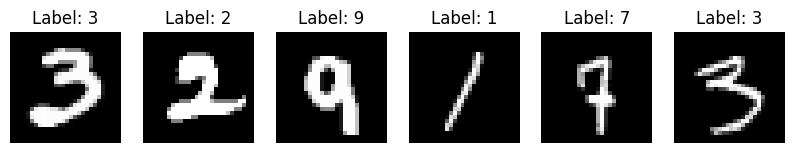

In [3]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(10, 3))
for i in range(6):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Label: {labels[i].item()}')
plt.show()

## Part 3: Implement VAE

### TODO - Implement reparameterize function

In [4]:
import torch
from torch import nn

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
        )
        self.mu = nn.Linear(400, latent_dim)
        self.log_var = nn.Linear(400, latent_dim)

    def forward(self, x):
        h = self.enc(x)
        return self.mu(h), self.log_var(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.dec(z)

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        # TODO: given mu and log_var of a normal distribution write a function
        #   that returns a sample from the distribution
        std = torch.exp(0.5*log_var)
        eps = torch.normal(mean=0,std=1,size=mu.shape).to(device)
        return mu+eps*std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decoder(z)
        return recon_x, mu, log_var


### TODO - implement the vae loss

A Variational Autoencoder loss typically has two components:
  - Reconstruction loss
  - Measures how accurately the model reconstructs the input.
  - Typically binary cross-entropy for MNIST (pixel intensities are between 0 and 1). Also consider MSE.

KL Divergence loss
  - Measures how much the learned latent distribution deviates from a standard Gaussian distribution.
  - Ensures latent space regularity.

In [5]:
def vae_loss(recon_x, x, mu, log_var):
    # Reconstruction Loss:
    # Measures how accurately the decoded output matches the original input.
    # TODO: Implement reconstruction loss given recon_x and x
    recon_loss=nn.functional.mse_loss(recon_x,x,reduction='sum')

    # KL Divergence Loss:
    # Measures how much the learned latent distribution deviates
    # from a standard Gaussian distribution (prior).
    # TODO: Implement KL_loss given mu and log_var
    kl_loss=-0.5*torch.sum(1 +log_var-mu.pow(2)-log_var.exp())

    # Total loss combines both terms
    loss = recon_loss + kl_loss

    return loss, recon_loss, kl_loss


In [6]:
# The code runs faster if you run on GPU. Select Runtime -> Change runtime type -> T4 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

# Part 4: Train the model

### [TODO] - Implement the training loop



In [7]:
model = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15
train_losses = []
kl_losses = []
recon_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_kl = 0
    total_recon = 0
    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)
        optimizer.zero_grad()

        # Compute model predictions
        recon_x, mu, log_var = model(x)

        # Compute losses
        loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, log_var)

        # Run backward and optimizer
        loss.backward()
        optimizer.step()


        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    # Compute average loss and store it
    train_losses.append(total_loss / len(train_loader))
    recon_losses.append(total_recon / len(train_loader))
    kl_losses.append(total_kl / len(train_loader))

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}')


Epoch [1/15], Loss: 6255.4857
Epoch [2/15], Loss: 5346.3501
Epoch [3/15], Loss: 5206.5119
Epoch [4/15], Loss: 5134.6155
Epoch [5/15], Loss: 5083.8791
Epoch [6/15], Loss: 5046.9049
Epoch [7/15], Loss: 5015.2983
Epoch [8/15], Loss: 4984.1915
Epoch [9/15], Loss: 4956.1839
Epoch [10/15], Loss: 4934.9055
Epoch [11/15], Loss: 4912.1154
Epoch [12/15], Loss: 4892.7438
Epoch [13/15], Loss: 4872.6702
Epoch [14/15], Loss: 4853.5048
Epoch [15/15], Loss: 4838.2757


# Part 5: Analyze Results

### TODOs

Clearly plot the following curves and include explanations for each:

#### 1. Plot the total training loss (average per epoch).

#### 2. Plot the reconstruction loss and KL divergence loss separately on the same plot (clearly labeled).

#### 3. Did the model converge? Which loss dominates and why?
<div dir="rtl" align="justify">
بله مدل همگرا شده است زیرا خطای آموزش بعد از ایپاک 8ام در طی اضافه شدن ایپاک ها تغییر چشمگیری ندارد و به سمت یک خط صاف میل میکند.
همچنین خطای بازسازی نسبت به خطای KL قالب تر است زیرا خطای بازسازی هم در حالتی که BCE در نظر گرفته شود و هم در این حالت که MSE در نظر گرفته شده مقدار خطایی که برمیگرداند در مقیاس بزرگتری است.</div>



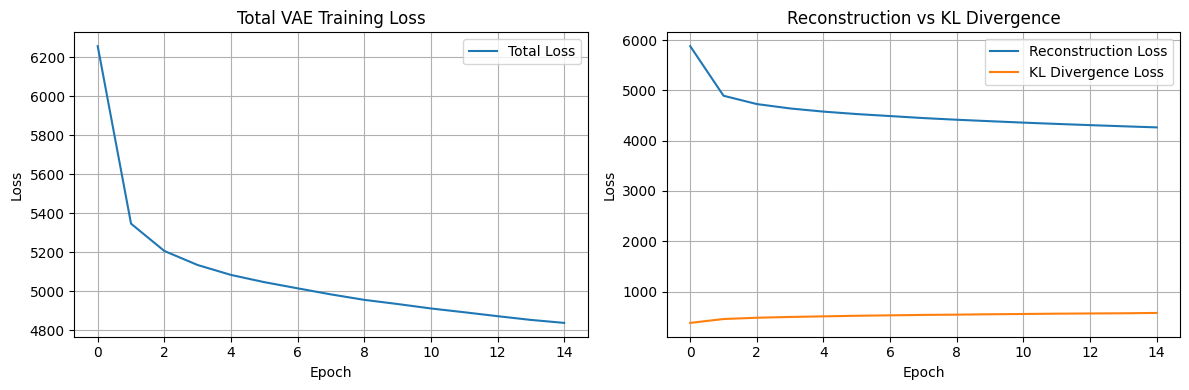

In [8]:
# Assume train_losses, recon_losses, kl_losses were stored during training

plt.figure(figsize=(12,4))

# Plot total training loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Total Loss')
plt.title('Total VAE Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

# Plot Reconstruction and KL divergence separately
plt.subplot(1, 2, 2)
plt.plot(recon_losses, label='Reconstruction Loss')
plt.plot(kl_losses, label='KL Divergence Loss')
plt.title('Reconstruction vs KL Divergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


# Part 6: Generate and visualize samples

### TODO
 - Generate and visualize at least 16 samples from random latent vectors.
 - Comment on the sample qualities
 <div dir="rtl" align="justify">
نمونه های تولید شده بسیار بلور و مات هستند و بعضی از جفت عدد ها مانند 5 و 6 یا 8 و 1 مشابه یکدیگر تولید شده اند.</div>
 - Is there any way that you can increase the sample qualities?<div dir="rtl" align="justify">
 بله با روشهایی مانند تغییر ساختار مدل، اضافه کردن ایپاک ها و یا افزایش تعداد داده نمونه ها برای آموزش مدل میتواند به بهبود کیفیت تصاویری که تولید میشود کمک کند.</div>
    - Can you make changes to the architecture to improve the quality?
     <div dir="rtl" align="justify">
     بله میتوان تعداد لایه های پنهان و ابعاد آنها هم در encoder  و هم در decoder افزایش داد که باعث پیچیده تر شدن مدل میشود و میتواند به یادگیری بهتر مدل کمک کند. همچنین از آنجایی که داده های ما تصاویر هستند استفاده از ساختار CNN به جای ساختار موجود میتواند کیفیت را بهبود دهد زیرا این ساختار در داده های تصویر بهتر قادر به یادگیری داده های تصویر هستند.
     </div>
    - Can you change the reconstruction loss to improve the quality?
     <div dir="rtl" align="justify">
     بله تغییر در خطای بازسازی نیز در کیفیت نمونه های تولید شده تاثیرگذار است. به طور مثال در همین دیتاست نمونه های تولید شده با خطای BCE (Binary Cross-Entropy) کیفیت پایین تر داشتند و تصاویر بلور تر و مات تر بودند به همین دلیل در پیاده سازی از خطای MSE را که کیفیت بهتری داشتند جایگزین کردم. در پایین تصاویری که با خطای BCE تولید شده اند را میتوانیم ببینیم که تصاویر کیفیت پایینتری نسبت به تصاویر تولید شده با خطای MSE (خروجی کد) دارند:
     </div>


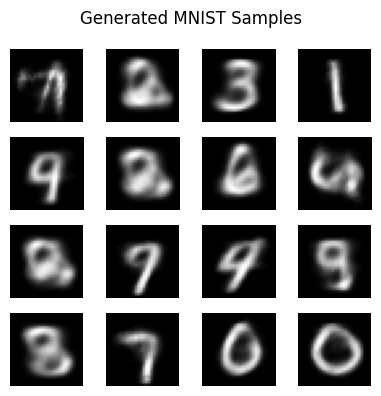

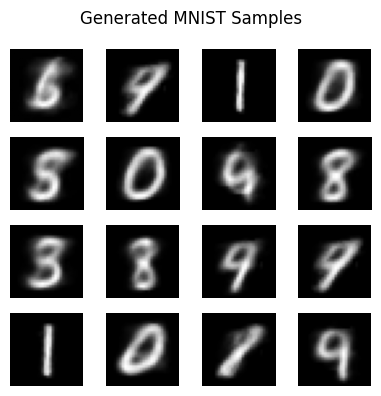

In [14]:
with torch.no_grad():
    # Generate random latent vectors
    z = torch.randn(16, model.encoder.mu.out_features).to(device)
    samples = model.decoder(z).cpu()

fig, axes = plt.subplots(4,4, figsize=(4,4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].view(28,28), cmap='gray')
    ax.axis('off')

plt.suptitle('Generated MNIST Samples')
plt.tight_layout()
plt.show()


# Part 7: Latent Space Visualization

### TODO
  - Decode all the items in the test set then visualize the encodings with scatterplot
  - Clearly label the plot with digit labels.
  - Interpret how well-separated or clustered digits appear.



<div dir="rtl" align="justify">
هر رقم بطور کلی در ناحیه‌ای متمایز قرار گرفته است و این نشان می‌دهد که مدل ویژگی‌ های مربوط به شکل ظاهری هر رقم را تا حد زیادی به‌ خوبی یاد گرفته. رقم‌هایی مثل 0 و  1  خوشه‌های جداگانه و متمرکزی را تشکیل داده اند و از  سایر ارقام فاصله گرفته اند. اما بعضی رقم ها مانند 3، 5 و 8 که مشابه‌ تر هستند هم‌ پوشانی بیشتری باهم دارند. با این حال بیشتر نقاطی که مربوط به یک رقم مشخص هستند در یک خوشه قرار گرفته اند و این نشان میدهد که  فضای پنهان مدل تفاوتهای بین ارقام را در ابعاد پایین‌ تر  خوب یاد گرفته.
</div>

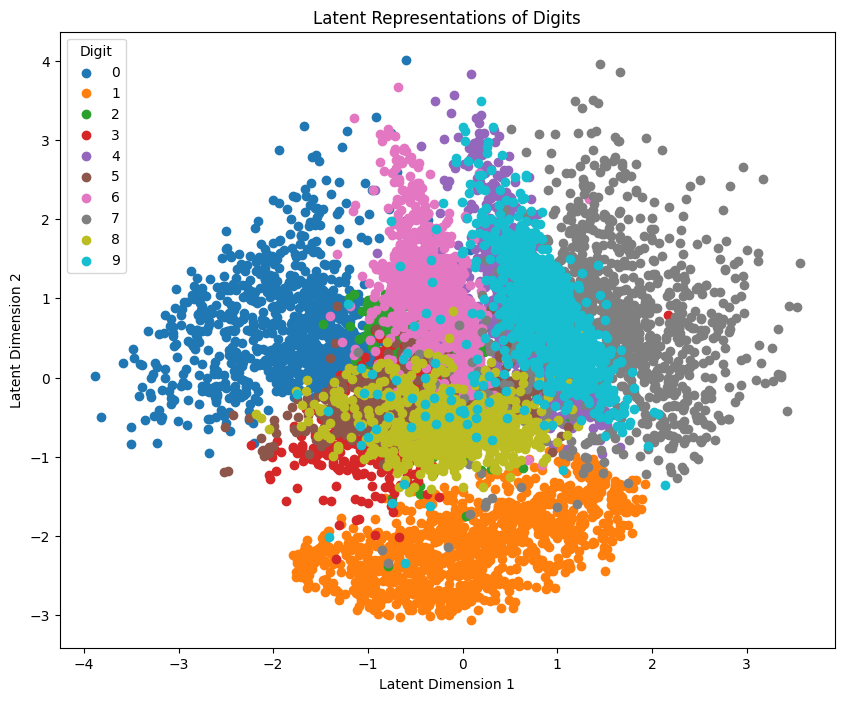

In [15]:
model.eval()
latents, labels_list = [], []

with torch.no_grad():
    for x, labels in test_loader:
        x = x.view(-1, 784).to(device)  # Correct shape for convolutional model
        # TODO: encode samples and store
        mu,log_var=model.encoder(x)
        z=mu
        latents.append(z.cpu())
        labels_list.append(labels)

# TODO: visualize the decoded samples

latents=torch.cat(latents,dim=0).numpy()
labels_list=torch.cat(labels_list,dim=0).numpy()

plt.figure(figsize=(10, 8))
for d in range(10):
    idx= labels_list==d
    plt.scatter(latents[idx,0],latents[idx,1],label=str(d))

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Latent Representations of Digits")
plt.legend(title="Digit")
plt.show()



# Part 8: Latent Space Interpolation
### TODO
  - Perform interpolation between pairs of test samples in the latent space.
  - Consider two samples—for example, one labeled '7' and the other '2'. Encode both samples, then interpolate between their encoded representations.
  - Decode interpolations and visualize transitions clearly.
  - Comment on smoothness and interpretability of transitions.

<div dir="rtl" align="justify">
همانطور که مشاهده میشود تصاویر به آرامی از عدد 2 ابتدا به عدد 6، سپس از عدد 6 به عدد  5 و از 5 به عدد 9 که چیزی شبیه و بین عدد 2 نوشته شده در سمت چپ و 7 نوشته شده در سمت راست است تغییر کرده است و سپس از 9 به رفته رفته به عدد 7 نزدیک شده و هر تصویر میانی ترکیبی از دو رقم انتهایی است.
 این  نشان می‌دهد که مدل ویژگی‌ های دیداری هر رقم را به طور مداوم در فضای پنهان حفظ کرده و درک ویژگی‌های ظاهری هر رقم میتواند بدون حرکت ناگهانی میان آنها حرکت کند.
</div>

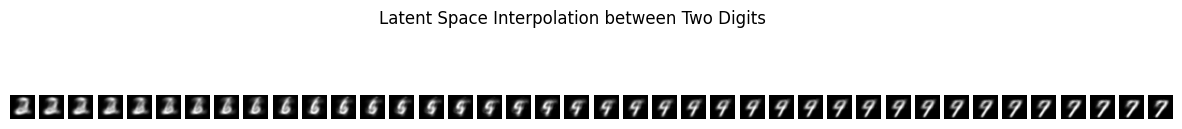

In [30]:
def interpolate(latent1, latent2, steps):
    ratios = torch.linspace(0, 1, steps).unsqueeze(1).to(latent1.device)
    interpolated = latent1 * (1 - ratios) + latent2 * ratios
    return interpolated

num_steps = 40


with torch.no_grad():
    # Select two random images
    x1=train_dataset[torch.where(train_dataset.targets==2)[0][5]][0].view(-1,784).to(device) # select a sample from dataset
    x2=train_dataset[torch.where(train_dataset.targets==7)[0][5]][0].view(-1,784).to(device) # select another sample from dataset

    # encode both samples using the model's encoder
    x1_encoded = model.encoder(x1)[0]
    x2_encoded = model.encoder(x2)[0]
    # then create interpolated encodings between both encodings
    interpolated_encodings=interpolate(x1_encoded,x2_encoded,num_steps)
    # decode the interpolated encodings to create the images
    decoded_images=model.decoder(interpolated_encodings).cpu()

fig, axes = plt.subplots(1, num_steps, figsize=(15,2))
for i, ax in enumerate(axes):
    ax.imshow(decoded_images[i].view(28,28), cmap='gray')
    ax.axis('off')

plt.suptitle('Latent Space Interpolation between Two Digits')
plt.show()
